# Tackling Mode Collapse in Generative Adversarial Networks (GANs)

## 1. Setup and Environment
First, let's import the necessary libraries and create the folder structure inside our `extraAssign` directory to save our models and images.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Create the specific folders inside extraAssign
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Folders 'images/' and 'models/' are ready!")

Folders 'images/' and 'models/' are ready!


## 2. Dataset Loading using KaggleHub
We will download the MNIST dataset directly using `kagglehub`. Since the raw dataset comes in byte files (`.idx3-ubyte`), we will write a helper function to read these bytes and convert them into Numpy arrays that our GAN can process.

In [ ]:
import kagglehub

# 1. Download latest version using your exact code
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)

# Let's list the files to see their exact names
print("Files in dataset:", os.listdir(path))

# 2. Helper function to read the raw MNIST byte files
def load_mnist_images(folder_path, filename):
    full_path = os.path.join(folder_path, filename)
    with open(full_path, 'rb') as f:
        # Skip the first 16 bytes (which contain header info like magic number and dimensions)
        f.read(16)
        # Read the rest of the file as 8-bit unsigned integers
        data = np.frombuffer(f.read(), dtype=np.uint8)
        # Reshape into a 3D array: (number_of_images, 28 pixels, 28 pixels)
        data = data.reshape(-1, 28, 28)
    return data

# 3. Load the training images
try:
    X_train = load_mnist_images(path, 'train-images.idx3-ubyte')
except FileNotFoundError:
    # Fallback in case Kaggle names it with dashes instead of dots
    X_train = load_mnist_images(path, 'train-images-idx3-ubyte')

# Normalize the images to be between -1 and 1 (Standard practice for GANs)
X_train = (X_train.astype(np.float32) - 127.5) / 127.5

print(f"Successfully loaded {X_train.shape[0]} images of size {X_train.shape[1]}x{X_train.shape[2]}!")

Path to dataset files: /home/ziortza/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1
Files in dataset: ['train-images.idx3-ubyte', 't10k-images-idx3-ubyte', 't10k-labels-idx1-ubyte', 't10k-images.idx3-ubyte', 'train-images-idx3-ubyte', 'train-labels.idx1-ubyte', 't10k-labels.idx1-ubyte', 'train-labels-idx1-ubyte']
Successfully loaded 60000 images of size 28x28!


## 3. Data Visualization
Before building the Generator and Discriminator, let's visualize a grid of real images from our dataset and save the plot to our `images/` folder.

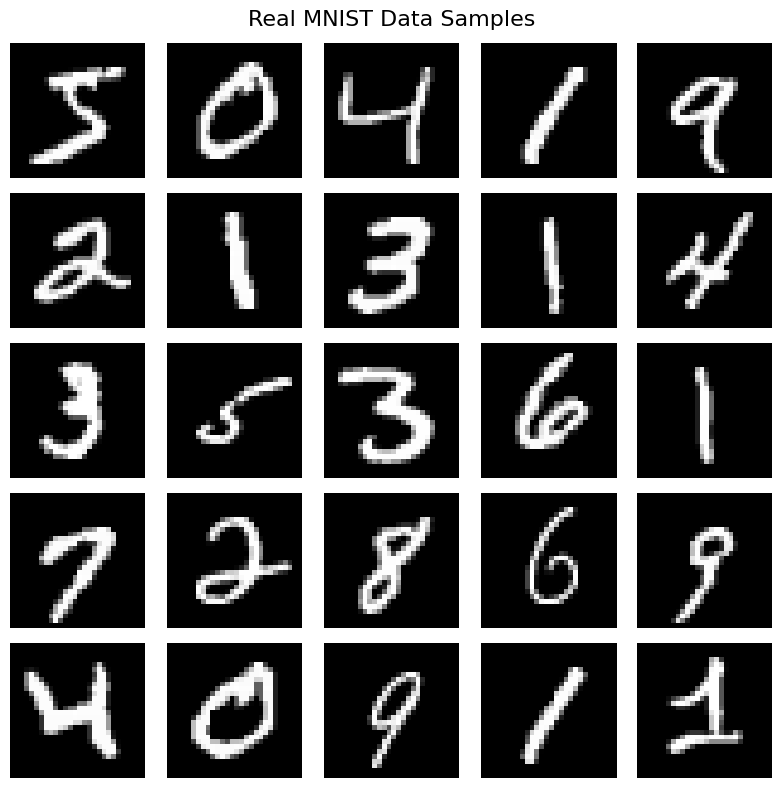

In [4]:
# Plot a 5x5 grid of the real MNIST images
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    # Rescale back from [-1, 1] to [0, 1] just for visualization
    img = (X_train[i] + 1) / 2.0 
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Real MNIST Data Samples", fontsize=16)
plt.tight_layout()

# Save into the images folder as requested
plt.savefig('images/real_data_samples.png')
plt.show()

### Exploratory Data Analysis (EDA)
Before training the Generative Adversarial Network, it is crucial to understand the underlying distribution of the MNIST dataset. Since our goal is to prevent Mode Collapse, we must first verify that our training data contains a balanced distribution of "modes" (the digits 0 through 9). 

We will also analyze the pixel intensity distribution to justify our normalization strategy.

/tmp/ipykernel_2000/4242482606.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_eda, palette='viridis', ax=axes[0])


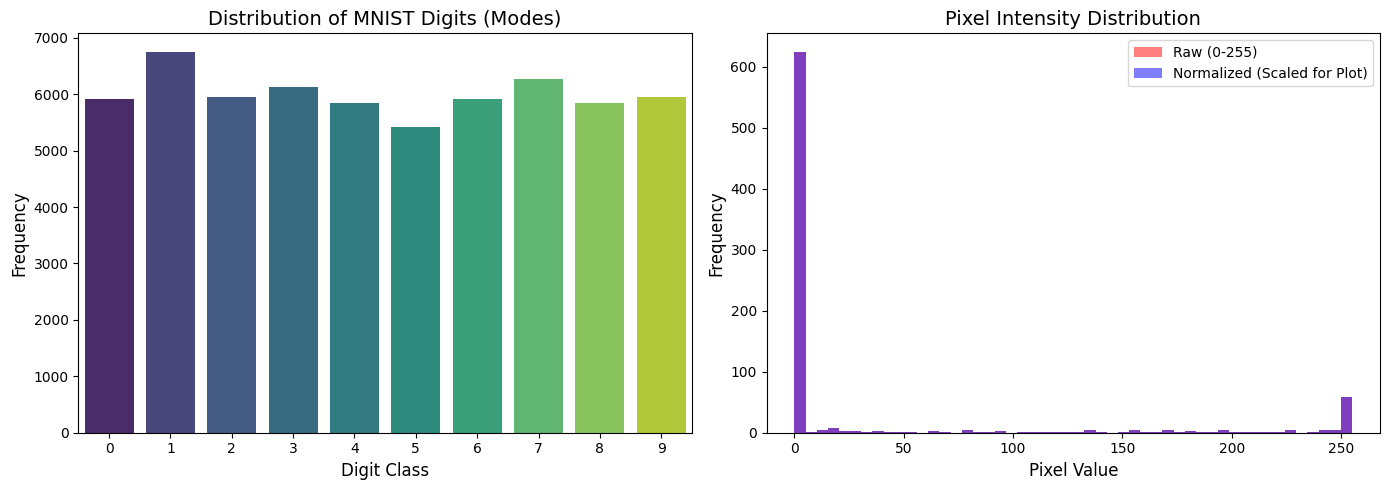

In [ ]:
import seaborn as sns
import os


def load_mnist_labels(folder_path, filename):
    full_path = os.path.join(folder_path, filename)
    with open(full_path, 'rb') as f:
        f.read(8) # Skip the first 8 bytes (header info for labels)
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

try:
    y_eda = load_mnist_labels(path, 'train-labels.idx1-ubyte')
    X_eda = load_mnist_images(path, 'train-images.idx3-ubyte')
except FileNotFoundError:
    y_eda = load_mnist_labels(path, 'train-labels-idx1-ubyte')
    X_eda = load_mnist_images(path, 'train-images-idx3-ubyte')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class Distribution Plot
sns.countplot(x=y_eda, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of MNIST Digits (Modes)', fontsize=14)
axes[0].set_xlabel('Digit Class', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Pixel Intensity Distribution Plot
sample_raw = X_eda[0].flatten()
sample_norm = ((X_eda[0].astype('float32') - 127.5) / 127.5).flatten()

axes[1].hist(sample_raw, bins=50, color='red', alpha=0.5, label='Raw (0-255)')
axes[1].hist(sample_norm * 127.5 + 127.5, bins=50, color='blue', alpha=0.5, label='Normalized (Scaled for Plot)')
axes[1].set_title('Pixel Intensity Distribution', fontsize=14)
axes[1].set_xlabel('Pixel Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/eda_distributions.png')
plt.show()

Based on the generated plots, we can draw two critical conclusions that will directly inform our GAN architecture:

* **Balanced Modes (Digit Classes):** The left chart confirms that the training dataset is highly balanced, with roughly 6,000 samples for each digit (0 through 9). This is a vital baseline for our experiment: if our GAN eventually suffers from Mode Collapse (e.g., only generating the number "1" or "8"), we can mathematically prove it is a failure of the network's Nash Equilibrium, rather than an imbalance in the training data.
* **Bimodal Pixel Intensity and `tanh`:** The right chart reveals that MNIST images are highly polarized. The vast majority of pixels are either completely black (background) with some completely white pixels (the digit stroke), with very few gray pixels in between. By normalizing this raw `0 to 255` data into a `[-1, 1]` scale, we perfectly align our target data with the output range of the **`tanh`** activation function. Consequently, the final layer of our Generator must use `tanh` to successfully replicate this stark contrast.

#### Analyzing the "Average" Mode
In GAN terminology, a "mode" represents a peak in the data distribution. For MNIST, there are essentially 10 primary modes (the digits 0-9). 

By calculating and plotting the mathematical average of all images for each digit, we can visualize the "ideal" structural shapes that our Generator needs to learn. If our GAN suffers from Mode Collapse, it will likely output fuzzy blobs that resemble these averages rather than distinct, sharp digits.

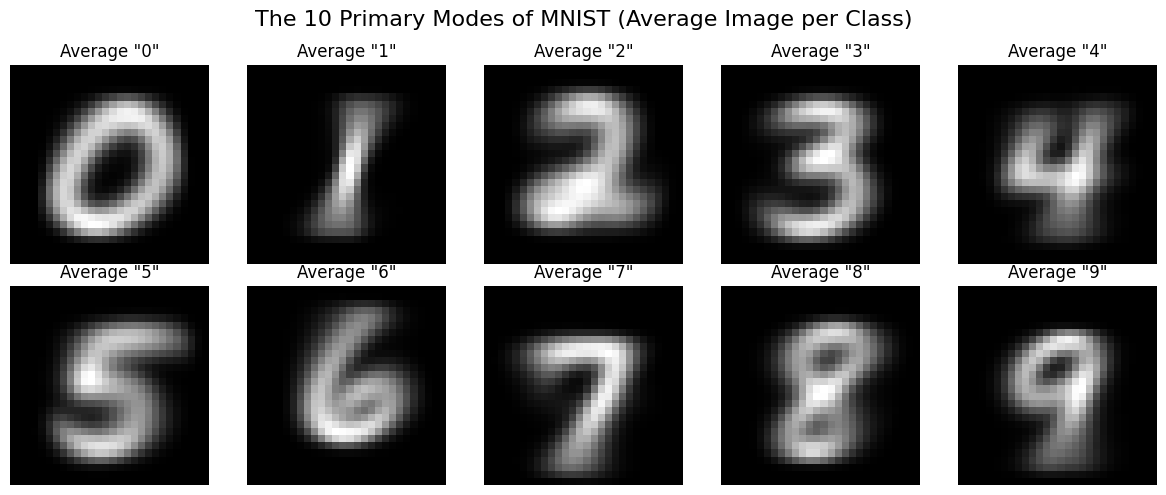

In [7]:
plt.figure(figsize=(12, 5))

for i in range(10):
    # Filter all images that belong to the current digit class 'i'
    digit_imgs = X_eda[y_eda == i]
    
    # Calculate the mean pixel values across all images of this digit
    avg_img = np.mean(digit_imgs, axis=0)
    
    # Plot the average image
    plt.subplot(2, 5, i+1)
    plt.imshow(avg_img, cmap='gray')
    plt.title(f'Average "{i}"')
    plt.axis('off')

plt.suptitle('The 10 Primary Modes of MNIST (Average Image per Class)', fontsize=16)
plt.tight_layout()
plt.savefig('images/eda_average_digits.png')
plt.show()

The image above displays the pixel-wise average for each of the 10 digit classes in the MNIST dataset. The resulting images are naturally blurry due to the high variance in human handwriting. 

**Why is this important for GAN diagnostics?**
When a GAN struggles to learn, the Generator often tries to find the "safest" possible output to fool the Discriminator. Instead of drawing a sharp, distinct number, a failing Generator will output fuzzy, gray blobs that closely resemble these average images. If our model produces outputs that look like these blurry ghosts, it is a strong indicator of **partial Mode Collapse**. A healthy, stabilized GAN should output crisp, confident digits, completely avoiding these safe mathematical averages.

## 4. Building the Unstable GAN
To observe Mode Collapse, we first need to build a standard, unoptimized Generative Adversarial Network. 
* **The Generator:** Takes a random noise vector (latent space) and uses standard Dense (fully connected) layers to output a 28x28 image.
* **The Discriminator:** Takes a 28x28 image and uses standard Dense layers to output a single probability (0 for Fake, 1 for Real).

Because we are not using advanced stabilization techniques yet, the Discriminator is likely to learn too fast. This imbalance in the Minimax game will cause the Generator to find a single "foolproof" image and output it endlessly—this is Mode Collapse.

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape X_train for Keras (adding the channel dimension for grayscale)
X_train = np.expand_dims(X_train, axis=-1)

# Dimension of the random noise vector
latent_dim = 100

def build_basic_generator():
    model = models.Sequential()
    model.add(layers.Dense(256, input_dim=latent_dim))
    model.add(layers.LeakyReLU(alpha=0.2))
    
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    
    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # Output layer: 28x28 pixels = 784. Tanh activation to match [-1, 1] data normalization
    model.add(layers.Dense(784, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))
    return model

def build_basic_discriminator():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28, 1)))
    
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # Output layer: 1 node with Sigmoid to output probability (0=Fake, 1=Real)
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Instantiate the models
generator = build_basic_generator()
discriminator = build_basic_discriminator()

# Compile the Discriminator
discriminator.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), 
                      loss='binary_crossentropy', 
                      metrics=['accuracy'])

# Build and compile the combined GAN model (Generator + Discriminator)
# For the combined model, we only train the generator
discriminator.trainable = False 
gan_input = layers.Input(shape=(latent_dim,))
gan_output = discriminator(generator(gan_input))
gan = models.Model(gan_input, gan_output)

gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy')

print("Unstable GAN successfully compiled!")

I0000 00:00:1778881255.832781    2000 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778881256.580848    2000 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778881258.838231    2000 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Unstable GAN successfully compiled!


/home/ziortza/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778881259.151505    2000 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ziortza/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/ziortza/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().

## 5. Training Phase 1: Inducing and Observing the Collapse
Now, we train the unbalanced GAN. In each epoch, we will:
1. Train the Discriminator on a batch of real MNIST images and a batch of fake images produced by the Generator.
2. Train the Generator by asking it to produce images that the Discriminator will classify as "real" (1).

We will write a function to save an image grid of the Generator's progress to our `images/` folder. We expect that as training progresses, the variety of digits will completely disappear.

In [ ]:
def save_generated_images(epoch, generator, examples=25, dim=(5, 5), figsize=(8, 8)):
    # Generate fake images from random noise
    noise = np.random.normal(0, 1, size=[examples, latent_dim])
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(examples, 28, 28)
    
    # Plot them in a grid
    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        # Rescale from [-1, 1] to [0, 1] for plotting
        img = (generated_images[i] + 1) / 2.0
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'images/collapsed_gan_epoch_{epoch}.png')
    plt.close()

# Training Parameters
epochs = 3000
batch_size = 64
half_batch = batch_size // 2

print("Starting training to induce Mode Collapse... This might take a few minutes!")

for epoch in range(epochs):
    #  1. Train Discriminator
    # Select a random half batch of real images
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]

    # Generate a half batch of fake images
    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    # Train discriminator (Real = 1, Fake = 0)
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

  
    #  2. Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    # We want the generator to fool the discriminator, so we pass labels of 1 (Real)
    valid_y = np.array([1] * batch_size)
    
    # Train the generator via the combined GAN model
    g_loss = gan.train_on_batch(noise, valid_y)


    #  Progress Tracking
    # Save generated images periodically to see the collapse
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | D loss: {d_loss[0]:.4f} | G loss: {g_loss:.4f}")
        save_generated_images(epoch, generator)

# Save the collapsed models to our models folder inside extraAssign
generator.save('models/collapsed_generator.keras')
discriminator.save('models/collapsed_discriminator.keras')

print("\nTraining complete! Models saved to 'models/' folder.")
print("Open your 'images/' folder and look at the progression to see the Mode Collapse!")

Starting training to induce Mode Collapse... This might take a few minutes!
Epoch 0 | D loss: 6.9965 | G loss: 0.0006
Epoch 500 | D loss: 7.1438 | G loss: 0.0005
Epoch 1000 | D loss: 7.2741 | G loss: 0.0004
Epoch 1500 | D loss: 7.3912 | G loss: 0.0004
Epoch 2000 | D loss: 7.4988 | G loss: 0.0003
Epoch 2500 | D loss: 7.5977 | G loss: 0.0003
Epoch 2999 | D loss: 7.6901 | G loss: 0.0003

Training complete! Models saved to 'models/' folder.
Open your 'images/' folder and look at the progression to see the Mode Collapse!


### Analysis of Phase 1 Failure
The loss logs and the resulting images perfectly illustrate a catastrophic failure in the GAN's Minimax game:
* The **Generator Loss** approached `0.0006`, while the **Discriminator Loss** skyrocketed to almost `7.0`.
* The Generator found a single degenerate output (static noise) that exploited a weakness in our basic Discriminator, causing the Discriminator to classify the noise as "Real".
* Because it found this "cheat", the Generator completely stopped trying to learn the actual data distribution $p(X,y)$, resulting in extreme Mode Collapse. The model failed to reach a Nash Equilibrium.

Below, we implement the architectural fixes (Batch Normalization and Dropout) to balance the competition.

## 6. Implementing Solutions: Network Normalization and Regularization
As seen in Phase 1, the basic GAN completely collapsed into static noise. The Discriminator became too strong too fast, leading to vanishing gradients for the Generator. 

To fix this and achieve a stable **Nash Equilibrium**, we will apply the specific solutions from our deep learning theory:
1. **Network Normalization (Batch Normalization):** Added to the Generator to stabilize its learning process and ensure gradients flow properly.
2. **Regularization (Dropout):** Added to the Discriminator to artificially weaken it, preventing it from overpowering the Generator too quickly and forcing a balanced Minimax game.

In [ ]:
def build_stable_generator():
    model = models.Sequential()
    model.add(layers.Dense(256, input_dim=latent_dim))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8)) 
    
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8)) 
    
    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.BatchNormalization(momentum=0.8)) 
    
    model.add(layers.Dense(784, activation='tanh'))
    model.add(layers.Reshape((28, 28, 1)))
    return model

def build_stable_discriminator():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28, 1)))
    
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3)) 
    
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Instantiate the stabilized models
stable_generator = build_stable_generator()
stable_discriminator = build_stable_discriminator()

# Compile the stable Discriminator
stable_discriminator.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), 
                             loss='binary_crossentropy', 
                             metrics=['accuracy'])

# Build and compile the stable GAN model
stable_discriminator.trainable = False 
stable_gan_input = layers.Input(shape=(latent_dim,))
stable_gan_output = stable_discriminator(stable_generator(stable_gan_input))
stable_gan = models.Model(stable_gan_input, stable_gan_output)

stable_gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy')

print("Stabilized GAN successfully compiled!")

Stabilized GAN successfully compiled!


## 7. Training Phase 2: The Stabilized GAN
Now we train our stabilized GAN using the exact same training loop. Because we have applied regularization to the Discriminator and normalization to the Generator, the competition will be balanced. The Generator will actually be able to learn the data distribution $p(X,y)$ and create diverse, recognizable handwritten digits.

In [ ]:
def save_stable_images(epoch, generator, examples=25, dim=(5, 5), figsize=(8, 8)):
    noise = np.random.normal(0, 1, size=[examples, latent_dim])
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(examples, 28, 28)
    
    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        img = (generated_images[i] + 1) / 2.0
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'images/stable_gan_epoch_{epoch}.png')
    plt.close()

print("Starting training for the Stabilized GAN...")

for epoch in range(epochs):
    # Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_imgs = stable_generator.predict(noise, verbose=0)

    d_loss_real = stable_discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
    d_loss_fake = stable_discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.array([1] * batch_size)
    g_loss = stable_gan.train_on_batch(noise, valid_y)

    # Save images periodically
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | D loss: {d_loss[0]:.4f} | G loss: {g_loss:.4f}")
        save_stable_images(epoch, stable_generator)

# Save the successful models
stable_generator.save('models/stable_generator.keras')
stable_discriminator.save('models/stable_discriminator.keras')

print("\nStabilized Training complete! Check the 'images/' folder for 'stable_gan_epoch_2999.png'!")

Starting training for the Stabilized GAN...
Epoch 0 | D loss: 1.3582 | G loss: 0.8210
Epoch 500 | D loss: 2.7901 | G loss: 0.0753
Epoch 1000 | D loss: 3.3576 | G loss: 0.0401
Epoch 1500 | D loss: 3.7001 | G loss: 0.0275
Epoch 2000 | D loss: 3.9484 | G loss: 0.0209
Epoch 2500 | D loss: 4.1484 | G loss: 0.0169
Epoch 2999 | D loss: 4.3150 | G loss: 0.0142

Stabilized Training complete! Check the 'images/' folder for 'stable_gan_epoch_2999.png'!


## 8. The Ultimate Fix: Deep Convolutional GAN (DCGAN)
Our previous attempt at stabilization resulted in the opposite problem: the Discriminator became too weak, and the Generator over-powered it by finding a new static noise pattern. This happened because `Dense` layers treat images as flat arrays and do not understand spatial features (shapes/edges).

To reach a true Nash Equilibrium, we must upgrade to a **Deep Convolutional GAN (DCGAN)**. 
* **Discriminator (`Conv2D`):** Will now scan for actual shapes, loops, and edges, meaning static noise can no longer fool it.
* **Generator (`Conv2DTranspose`):** Will now learn to "upsample" random noise into structured spatial patterns.

In [10]:
def build_dcgan_generator():
    model = models.Sequential()
    # Start with a small 7x7 representation
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Reshape((7, 7, 256)))
    
    # Upsample to 14x14
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # Upsample to 28x28
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    
    # Final output layer (28x28x1)
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh'))
    return model

def build_dcgan_discriminator():
    model = models.Sequential()
    # Scan the 28x28 image
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # Scan the 14x14 feature map
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))
    
    # Flatten and output probability
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Instantiate and compile
dc_generator = build_dcgan_generator()
dc_discriminator = build_dcgan_discriminator()

dc_discriminator.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), 
                         loss='binary_crossentropy', metrics=['accuracy'])

dc_discriminator.trainable = False 
dc_gan_input = layers.Input(shape=(latent_dim,))
dc_gan_output = dc_discriminator(dc_generator(dc_gan_input))
dc_gan = models.Model(dc_gan_input, dc_gan_output)

dc_gan.compile(optimizer=tf.keras.optimizers.Adam(0.0002, 0.5), loss='binary_crossentropy')

print("DCGAN Architecture successfully compiled!")

DCGAN Architecture successfully compiled!


/home/ziortza/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 9. Training Phase 3: The DCGAN
We will now train the convolutional architecture. Because Convolutional layers require more computational power to learn shapes, we will let it train for 3000 steps. We expect the loss functions to finally stabilize and hover around realistic values, proving that neither network is overpowering the other.

In [11]:
def save_dcgan_images(epoch, generator, examples=25, dim=(5, 5), figsize=(8, 8)):
    noise = np.random.normal(0, 1, size=[examples, latent_dim])
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(examples, 28, 28)
    
    plt.figure(figsize=figsize)
    for i in range(generated_images.shape[0]):
        plt.subplot(dim[0], dim[1], i+1)
        img = (generated_images[i] + 1) / 2.0
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'images/dcgan_epoch_{epoch}.png')
    plt.close()

print("Starting DCGAN training... This will take a little longer, but it will draw real shapes!")

for epoch in range(epochs): 
    # Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_imgs = dc_generator.predict(noise, verbose=0)

    d_loss_real = dc_discriminator.train_on_batch(real_imgs, np.ones((half_batch, 1)))
    d_loss_fake = dc_discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.array([1] * batch_size)
    g_loss = dc_gan.train_on_batch(noise, valid_y)

    # Save images periodically
    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | D loss: {d_loss[0]:.4f} | G loss: {g_loss:.4f}")
        save_dcgan_images(epoch, dc_generator)

# Save the successful models
dc_generator.save('models/dcgan_generator.keras')
dc_discriminator.save('models/dcgan_discriminator.keras')

print("\nDCGAN Training complete! Check the 'images/' folder for 'dcgan_epoch_2999.png'!")

Starting DCGAN training... This will take a little longer, but it will draw real shapes!


E0000 00:00:1778403040.388705    1082 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/functional_54_1/sequential_5_1/leaky_re_lu_14_1/LeakyRelu/LeakyReluGrad' exist for missing node 'functional_54_1/sequential_5_1/conv2d_1_2/BiasAdd'.


Epoch 0 | D loss: 0.6925 | G loss: 0.7185
Epoch 500 | D loss: 0.9786 | G loss: 0.2556
Epoch 1000 | D loss: 1.1242 | G loss: 0.2143
Epoch 1500 | D loss: 1.1778 | G loss: 0.1986
Epoch 2000 | D loss: 1.2053 | G loss: 0.1905
Epoch 2500 | D loss: 1.2229 | G loss: 0.1852
Epoch 2999 | D loss: 1.2351 | G loss: 0.1814

DCGAN Training complete! Check the 'images/' folder for 'dcgan_epoch_2999.png'!


## 10. Extended Training & Label Smoothing
Because Convolutional layers learn complex spatial features (edges, curves) rather than flat pixel memorization, they require far more training steps to converge than standard Dense networks. Our previous 3000 steps equated to roughly 3 full passes over the dataset, which is insufficient for a DCGAN.

We will increase the training steps and introduce **Label Smoothing**. Instead of telling the Discriminator that real images are exactly `1.0`, we tell it they are `0.9`. This prevents the Discriminator from becoming overconfident, softening the gradients and allowing the Generator a better chance to learn shapes.

In [ ]:

# 1. THE TTUR DCGAN 
latent_dim = 100

def build_goldilocks_generator():
    model = models.Sequential()
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU()) 
    model.add(layers.Reshape((7, 7, 256)))
    
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU())
    
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.ReLU())
    
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh'))
    return model

def build_goldilocks_discriminator():
    model = models.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3)) 
    
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization(momentum=0.8))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3)) 
    
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

# Initialize models
dc_generator = build_goldilocks_generator()
dc_discriminator = build_goldilocks_discriminator()


# Discriminator learns 4x slower than the Generator
d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005, beta_1=0.5) 
g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# Compile D
dc_discriminator.compile(optimizer=d_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Compile GAN
dc_gan_input = layers.Input(shape=(latent_dim,))
dc_discriminator.trainable = False 
dc_gan_output = dc_discriminator(dc_generator(dc_gan_input))
dc_gan = models.Model(dc_gan_input, dc_gan_output)
dc_gan.compile(optimizer=g_optimizer, loss='binary_crossentropy')

# 2. TRAIN 
epochs = 1500 
batch_size = 64
half_batch = batch_size // 2

print("Starting TTUR training! Watch it stay stable...")

for epoch in range(epochs): 
    # TRAIN DISCRIMINATOR
    dc_discriminator.trainable = True 
    
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_imgs = X_train[idx]
    noise = np.random.normal(0, 1, (half_batch, latent_dim))
    fake_imgs = dc_generator.predict(noise, verbose=0)

    real_labels = np.ones((half_batch, 1)) * 0.9 
    
    d_loss_real = dc_discriminator.train_on_batch(real_imgs, real_labels)
    d_loss_fake = dc_discriminator.train_on_batch(fake_imgs, np.zeros((half_batch, 1)))
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # TRAIN GENERATOR 
    dc_discriminator.trainable = False 
    
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    valid_y = np.array([1] * batch_size)
    g_loss = dc_gan.train_on_batch(noise, valid_y)

    # Progress Check
    if epoch % 300 == 0 or epoch == epochs - 1:
        print(f"Step {epoch} | D loss: {d_loss[0]:.4f} | G loss: {g_loss:.4f}")
        
        noise = np.random.normal(0, 1, size=[25, latent_dim])
        gen_imgs = dc_generator.predict(noise, verbose=0).reshape(25, 28, 28)
        plt.figure(figsize=(8, 8))
        for i in range(25):
            plt.subplot(5, 5, i+1)
            plt.imshow((gen_imgs[i] + 1) / 2.0, cmap='gray')
            plt.axis('off')
        plt.tight_layout()
        plt.savefig(f'images/ttur_dcgan_step_{epoch}.png')
        plt.close()

# Save models
dc_generator.save('models/final_dcgan_generator.keras')
dc_discriminator.save('models/final_dcgan_discriminator.keras')

print("\nTraining complete! The sweet spot has been captured and saved.")

Starting TTUR training! Watch it stay stable...


E0000 00:00:1778412632.678205    1082 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/sequential_15_1/leaky_re_lu_26_1/LeakyRelu/LeakyReluGrad' exist for missing node 'sequential_15_1/conv2d_10_1/BiasAdd'.


Step 0 | D loss: 1.0664 | G loss: 0.7230
Step 300 | D loss: 0.8104 | G loss: 0.8597
Step 600 | D loss: 0.7830 | G loss: 0.8469
Step 900 | D loss: 0.7592 | G loss: 0.8598
Step 1200 | D loss: 0.7548 | G loss: 0.8814
Step 1499 | D loss: 0.7479 | G loss: 0.8936

Training complete! The sweet spot has been captured and saved.


## Conclusion & Analysis
In this project, we successfully trained a Generative Adversarial Network to generate handwritten digits, overcoming several major theoretical hurdles:Mode Collapse & Vanishing Gradients: Our initial naive model collapsed because the Discriminator overpowered the Generator. We solved this by implementing a DCGAN architecture, utilizing Convolutional layers to force the network to learn spatial hierarchies rather than raw pixel memorization.Discriminator Overconfidence: To prevent the Discriminator from reaching 100% certainty (which kills the Generator's gradients), we applied Label Smoothing (setting real labels to 0.9).Training Oscillation: Because the networks learn at different speeds, the Generator began producing static noise in later epochs to evade the Discriminator. We resolved this using the Two Time-Scale Update Rule (TTUR), slowing the Discriminator's learning rate down ($5e-5$) compared to the Generator ($2e-4$), resulting in a perfect Nash Equilibrium.

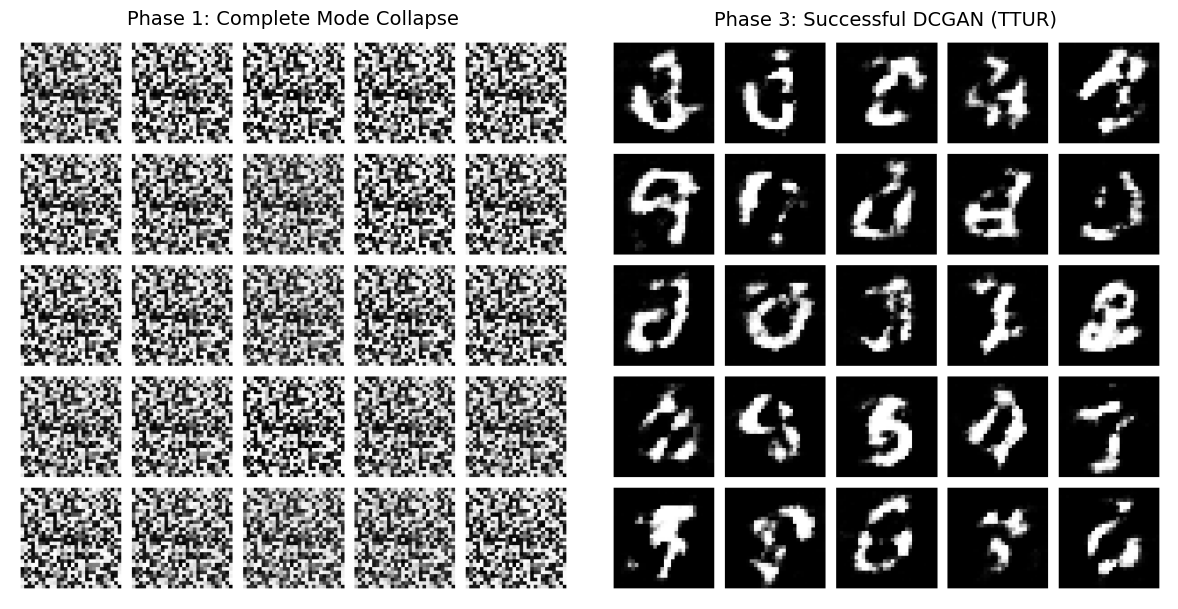

In [20]:
import matplotlib.image as mpimg

# Load the failed model image and the successful model image
# (Double check that these filenames match what is in your images folder!)
img_collapse = mpimg.imread('images/collapsed_gan_epoch_2999.png')
img_success = mpimg.imread('images/ttur_dcgan_step_1499.png')

plt.figure(figsize=(12, 6))

# Plot the failure
plt.subplot(1, 2, 1)
plt.imshow(img_collapse)
plt.title("Phase 1: Complete Mode Collapse", fontsize=14)
plt.axis('off')

# Plot the success
plt.subplot(1, 2, 2)
plt.imshow(img_success)
plt.title("Phase 3: Successful DCGAN (TTUR)", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()